# Esperimenti sul dataset con pazienti/malattie

## Il grafo è separato dai componenti di Protein e GO, togliendo anche gli Article
## Il grafo risultante è schematizzato così:

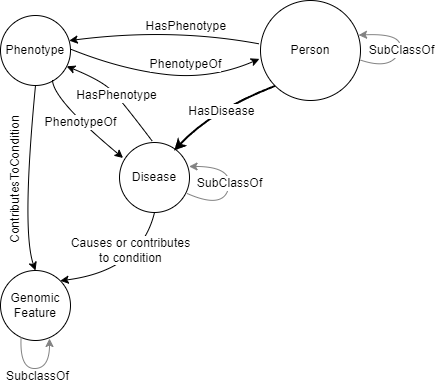

### Il grafo presenta (30'325 nodi e 148'056 archi), è stato snellito togliendo gli archi non coinvolti nelle sole malattie associate ai pazienti
### Sono quindi incluse tutte le connessioni che coinvolgono le malattie associate ai paziente e anche le loro malattie "parent"

## Test set creato esclusivamente sugli archi "Has disease"

##  Training senza definire delle feature, solamente sulla struttura del grafo

In [1]:
import os
import re
import matplotlib.pyplot as plt
import numpy as np
import math
from utilities import carica_file
from sklearn.decomposition import PCA

grid = ["l0.0005|d2", "l0.0005|d3","l0.0005|d10", "l0.0005|d25", "l0.01|d2", "l0.01|d3", "l0.01|d10", "l0.01|d25", "l0.09|d2", "l0.09|d3", "l0.09|d10", "l0.09|d25"]#, "l0.0005|d35", "l0.01|d35", "l0.09|d35"]

## Grid search esaustivo sugli iperparametri

In [2]:
from utilities import caricaLog

n = 1

dataset = "Pazienti senza features HGCN"
root_dir = "C:/Users/Lenovo/Desktop/1TESI MAGISTRALE/gridsearch/2026_1_20_gridHGCN" + str(n)
root_dir2 = "C:/Users/Lenovo/Desktop/1TESI MAGISTRALE/gridsearch/2026_1_20_gridGCN" + str(n)

all_train_roc, all_train_ap, all_val_roc, all_val_ap, all_test_roc, all_test_ap = caricaLog(root_dir, grid, False, False, False)
all_train_roc2, all_train_ap2, all_val_roc2, all_val_ap2, all_test_roc2, all_test_ap2 = caricaLog(root_dir2, grid, False, False, False)

## Stampo una iterazione di esempio

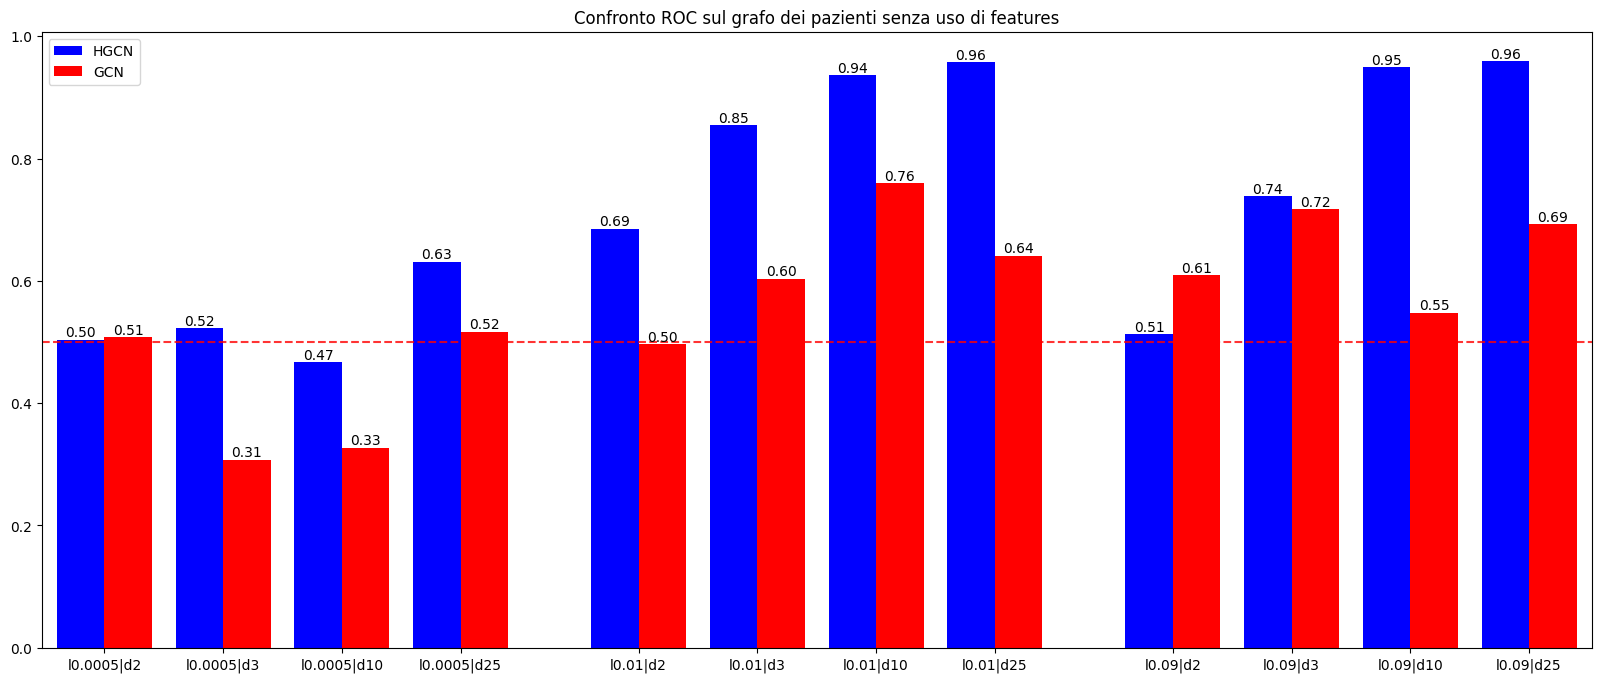

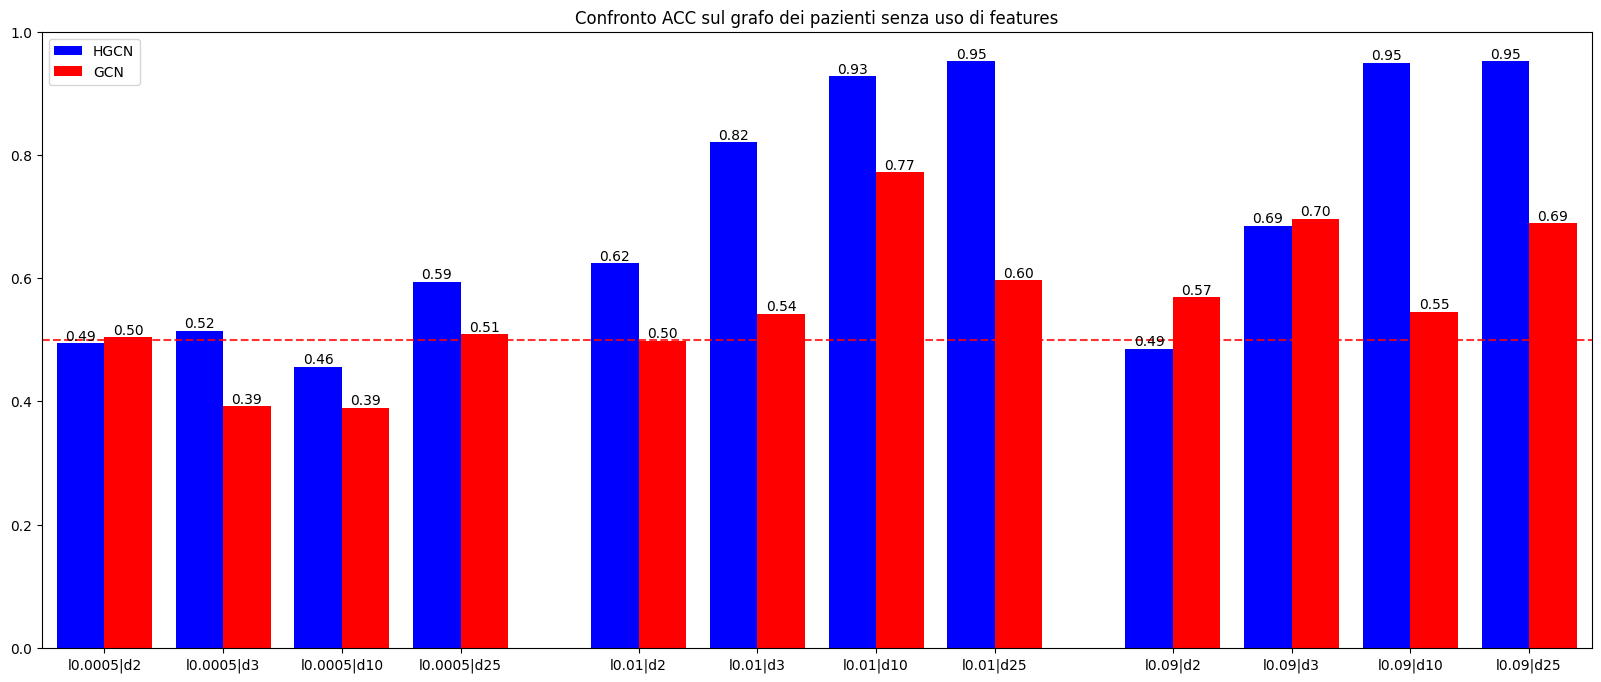

In [3]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(len(grid))
margin = 0.5
x = x + (x // 4) * margin
width = 0.4

plt.figure(figsize=(20, 8))
plt.axhline(0.5, color='red', linestyle='--', alpha=0.8)
plt.title("Confronto ROC sul grafo dei pazienti senza uso di features")

bars1 = plt.bar(x - width/2, all_test_roc, width, label='HGCN', color='blue')
bars2 = plt.bar(x + width/2, all_test_roc2, width, label='GCN', color='red')

plt.xticks(x, grid)
plt.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{height:.2f}",
            ha='center',
            va='bottom',
            fontsize=10
        )
plt.margins(x=0.01)
plt.show()

plt.figure(figsize=(20, 8))
plt.axhline(0.5, color='red', linestyle='--', alpha=0.8)
plt.title("Confronto ACC sul grafo dei pazienti senza uso di features")

bars1 = plt.bar(x - width/2, all_test_ap, width, label='HGCN', color='blue')
bars2 = plt.bar(x + width/2, all_test_ap2, width, label='GCN', color='red')

plt.xticks(x, grid)
plt.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{height:.2f}",
            ha='center',
            va='bottom',
            fontsize=10
        )
plt.margins(x=0.01)
plt.show()

In [4]:
z1 = []
z2 = []

for a, b in zip(all_test_ap, all_test_ap2):
    if a != 0:
        diff_percent = (b - a) / a * 100
        z1.append(diff_percent)
    else:
        print("Errore: divisione per zero")

for a, b in zip(all_test_roc, all_test_roc2):
    if a != 0:
        diff_percent = (b - a) / a * 100
        z2.append(diff_percent)
    else:
        print("Errore: divisione per zero")

print(f"La percentuale di guadagno di HGCN rispetto a GCN è:\n-Su ACC: {np.mean(z1):.2f}%\n-Su ROC: {np.mean(z2):.2f}%")
print(f"\nMaggior guadagno:\n-ACC: {grid[np.argmin(z1)]} ({np.min(z1):.2f})\n-ROC: {grid[np.argmin(z2)]} ({np.min(z2):.2f})")
print(f"\nMinor guadagno:\n-ACC: {grid[np.argmax(z1)]} ({np.max(z1):.2f})\n-ROC: {grid[np.argmax(z2)]} ({np.max(z2):.2f})")

La percentuale di guadagno di HGCN rispetto a GCN è:
-Su ACC: -17.53%
-Su ROC: -20.93%

Maggior guadagno:
-ACC: l0.09|d10 (-42.56)
-ROC: l0.09|d10 (-42.31)

Minor guadagno:
-ACC: l0.09|d2 (17.23)
-ROC: l0.09|d2 (18.84)


## Definisco funzione di peso per rendere esponenziale la crescita all'avvicinarsi a roc 0.98, per definire successivamente la funzione di efficienza

In [5]:
def weight(x):
    return np.exp(2.5*x)

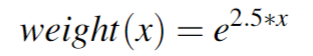

In [6]:
print(f"Tra 0.79 e 0.80:\t\t{weight(0.79):.3f} - {weight(0.8):.3f} ({(weight(0.8) - weight(0.79)):.3f})")
print(f"Tra 0.90 e 0.91:\t\t{weight(0.9):.3f} - {weight(0.91):.3f} ({(weight(0.91) - weight(0.9)):.3f})")

Tra 0.79 e 0.80:		7.207 - 7.389 (0.182)
Tra 0.90 e 0.91:		9.488 - 9.728 (0.240)


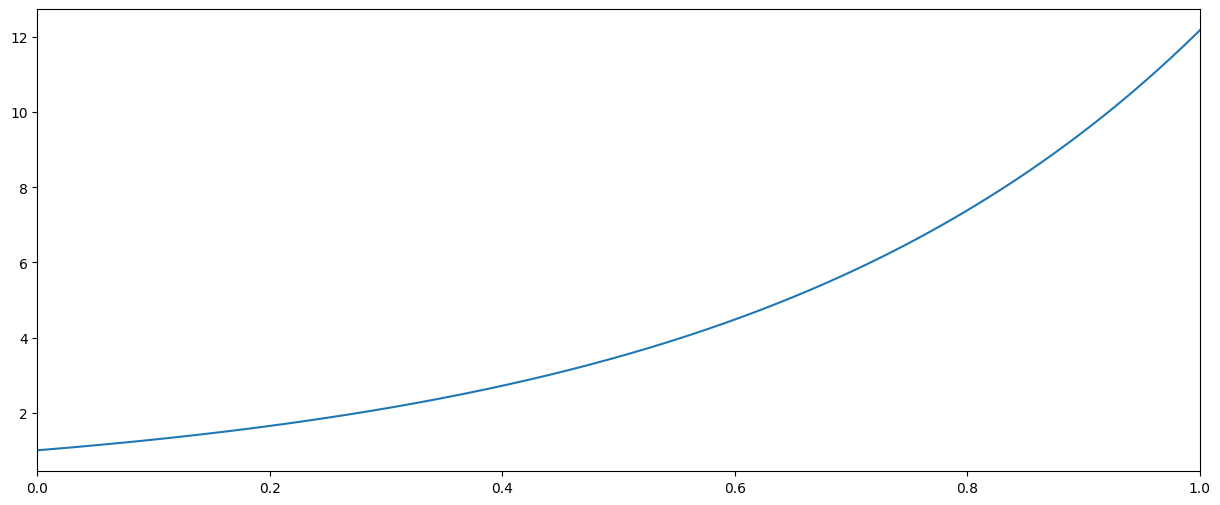

In [7]:
x = np.linspace(0, 1, 1000)
x2 = np.linspace(0, 1, 25)
plt.figure(figsize=(15, 6))
plt.plot(x, weight(x))
plt.xlim(0, 1)
plt.show()

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

root_dirs = [
    ("C:/Users/Lenovo/Desktop/1TESI MAGISTRALE/gridsearch/2026_1_20_gridHGCN1", "C:/Users/Lenovo/Desktop/1TESI MAGISTRALE/gridsearch/2026_1_20_gridGCN1"),
    ("C:/Users/Lenovo/Desktop/1TESI MAGISTRALE/gridsearch/2026_1_20_gridHGCN2", "C:/Users/Lenovo/Desktop/1TESI MAGISTRALE/gridsearch/2026_1_20_gridGCN2"),
    ("C:/Users/Lenovo/Desktop/1TESI MAGISTRALE/gridsearch/2026_1_20_gridHGCN3", "C:/Users/Lenovo/Desktop/1TESI MAGISTRALE/gridsearch/2026_1_20_gridGCN3")
]


rocHGCN = []
rocGCN = []
AVGtimeHGCN = []
AVGtimeGCN = []
SUMtimeHGCN = []
SUMtimeGCN = []
TOT, TOT2 = [], []

for (p1, p2) in root_dirs:

    all_test_roc, all_test_ap, tempi, total = carica_file(p1, grid)
    all_test_roc2, all_test_ap2, tempi2, total2 = carica_file(p2, grid)
    
    TOT.append(total)
    TOT2.append(total2)
    
    t1 = [np.sum(x) for x in tempi]
    t2 = [np.sum(x) for x in tempi2]
    
    a1 = [np.mean(x) for x in tempi]
    a2 = [np.mean(x) for x in tempi2]
    
    SUMtimeHGCN.append(t1)
    SUMtimeGCN.append(t2)
    
    AVGtimeHGCN.append(a1)
    AVGtimeGCN.append(a2)
    
    rocHGCN.append(all_test_roc)
    rocGCN.append(all_test_roc2)

effHGCN, effGCN = [], []
MeffHGCN, MeffGCN = [], []

for i in range(len(rocHGCN)):
    
    effHGCN.append((weight(np.array(rocHGCN[i]))/SUMtimeHGCN[i])/0.25)
    effGCN.append((weight(np.array(rocGCN[i]))/SUMtimeGCN[i])/0.25)

    MeffHGCN.append(np.array(rocHGCN[i])/AVGtimeHGCN[i])
    MeffGCN.append(np.array(rocGCN[i])/AVGtimeGCN[i])

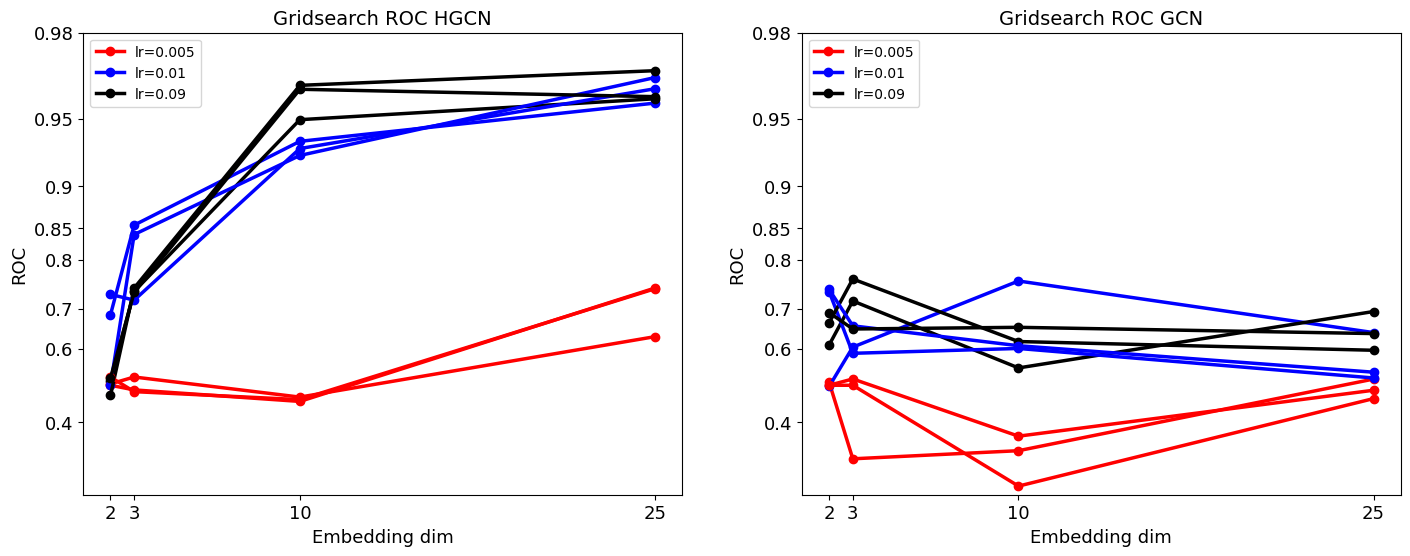

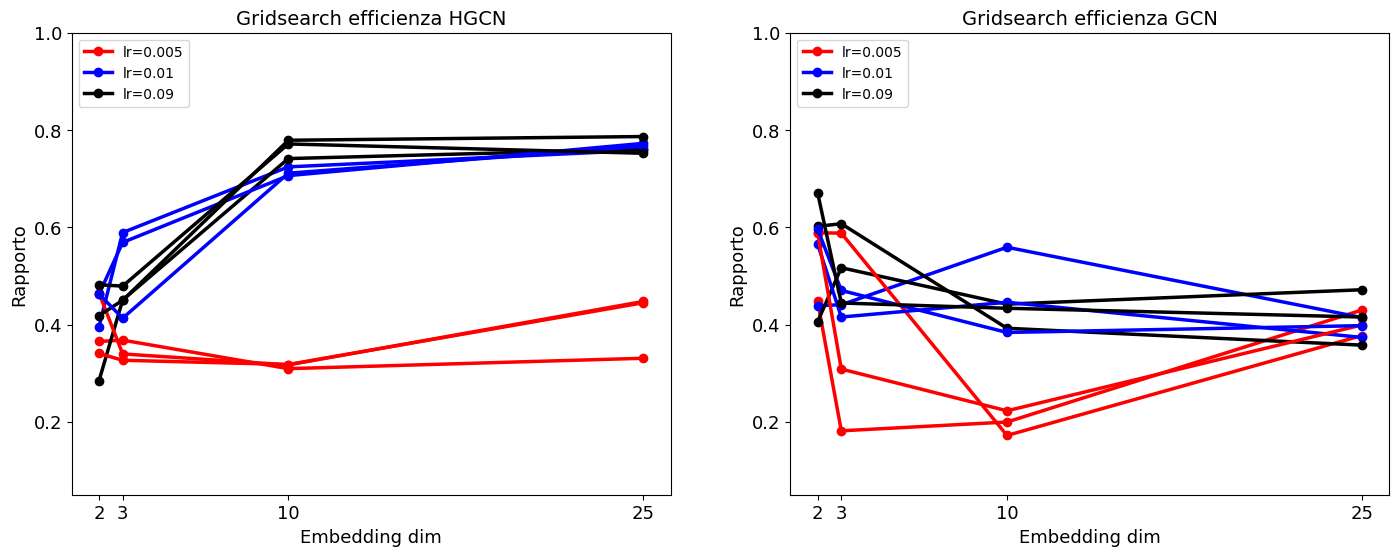

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from utilities import gridsearch

color = ["red", "blue", "black"]

dims = [2, 3, 10, 25]
lrs = [0.005, 0.01, 0.09]

gridsearch(color, dims, lrs, rocHGCN, rocGCN, "Gridsearch ROC", "ROC")
gridsearch(color, dims, lrs, effHGCN, effGCN, "Gridsearch efficienza", "Rapporto", True)

In [10]:
print("param"+"  ", "\t\t", "HGCN   (std)", "\t\033[1mTIME\033[0m\t", "GCN    (std)", "\t\t HGCN (std)\t", "\033[1mROC\033[0m\tGCN  (std)")
for i in range(len(grid)):
    if i%((len(grid)/4)+1) == 0:
        print("===========================================================================================================")
    a = np.mean(np.array(SUMtimeHGCN)[:, i])
    b = np.mean(np.array(SUMtimeGCN)[:, i])
    
    stdA = np.std(np.array(SUMtimeHGCN)[:, i])
    stdB = np.std(np.array(SUMtimeGCN)[:, i])
    
    rocA = np.mean(np.array(rocHGCN)[:, i])
    rocB = np.mean(np.array(rocGCN)[:, i])
    
    tstdA = np.std(np.array(rocHGCN)[:, i])
    tstdB = np.std(np.array(rocGCN)[:, i])
    
    
    if(a < b):
        if(rocA > rocB):
            print(f"{grid[i]}    \t\t \033[1m{a:.2f}\033[0m\t({stdA:.1f})\t\t {b:.2f}\t({stdB:.1f})\t\t \033[1m{rocA:.2f}\033[0m ({tstdA:.2f})\t\t{rocB:.2f} ({tstdB:.2f})")
        else:
            print(f"{grid[i]}    \t\t \033[1m{a:.2f}\033[0m\t({stdA:.1f})\t\t {b:.2f}\t({stdB:.1f})\t\t {rocA:.2f} ({tstdA:.2f})\t\t\033[1m{rocB:.2f}\033[0m ({tstdB:.2f})")
    else:
        if(rocA > rocB):
            print(f"{grid[i]}    \t\t {a:.2f}\t({stdA:.1f})\t\t \033[1m{b:.2f}\033[0m\t({stdB:.1f})\t\t \033[1m{rocA:.2f}\033[0m ({tstdA:.2f})\t\t{rocB:.2f} ({tstdB:.2f})")
        else:
            print(f"{grid[i]}    \t\t {a:.2f}\t({stdA:.1f})\t\t \033[1m{b:.2f}\033[0m\t({stdB:.1f})\t\t {rocA:.2f} ({tstdA:.2f})\t\t\033[1m{rocB:.2f}\033[0m ({tstdB:.2f})")

param   		 HGCN   (std) 	TIME	 GCN    (std) 		 HGCN (std)	 ROC	GCN  (std)
l0.0005|d2    		 37.34	(5.5)		 26.43	(3.8)		 0.51 (0.01)		0.50 (0.00)
l0.0005|d3    		 40.31	(0.5)		 39.53	(11.2)		 0.50 (0.02)		0.44 (0.10)
l0.0005|d10    		 40.28	(1.0)		 44.38	(0.9)		 0.46 (0.00)		0.31 (0.05)
l0.0005|d25    		 57.97	(0.4)		 33.81	(0.1)		 0.71 (0.05)		0.49 (0.02)
l0.01|d2    		 46.72	(11.7)		 39.74	(5.8)		 0.64 (0.10)		0.66 (0.11)
l0.01|d3    		 57.81	(0.4)		 42.34	(1.3)		 0.80 (0.06)		0.62 (0.03)
l0.01|d10    		 57.55	(0.2)		 45.22	(3.5)		 0.93 (0.00)		0.66 (0.07)
l0.01|d25    		 57.99	(0.2)		 41.91	(4.3)		 0.96 (0.00)		0.57 (0.05)
l0.09|d2    		 37.43	(9.4)		 37.94	(5.2)		 0.50 (0.02)		0.66 (0.03)
l0.09|d3    		 55.38	(2.0)		 45.58	(0.8)		 0.74 (0.00)		0.71 (0.05)
l0.09|d10    		 57.62	(0.3)		 43.62	(5.7)		 0.96 (0.01)		0.61 (0.04)
l0.09|d25    		 58.01	(0.5)		 48.37	(0.9)		 0.96 (0.00)		0.64 (0.04)


## Confronto diretto HGCN vs GCN

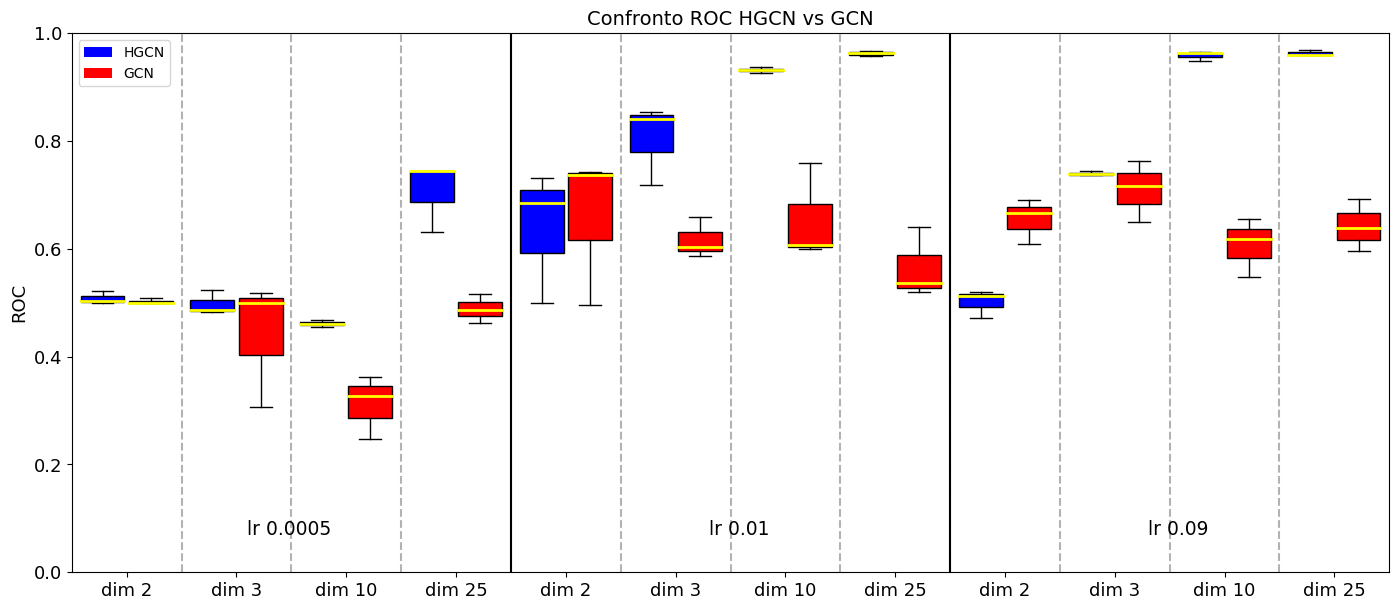

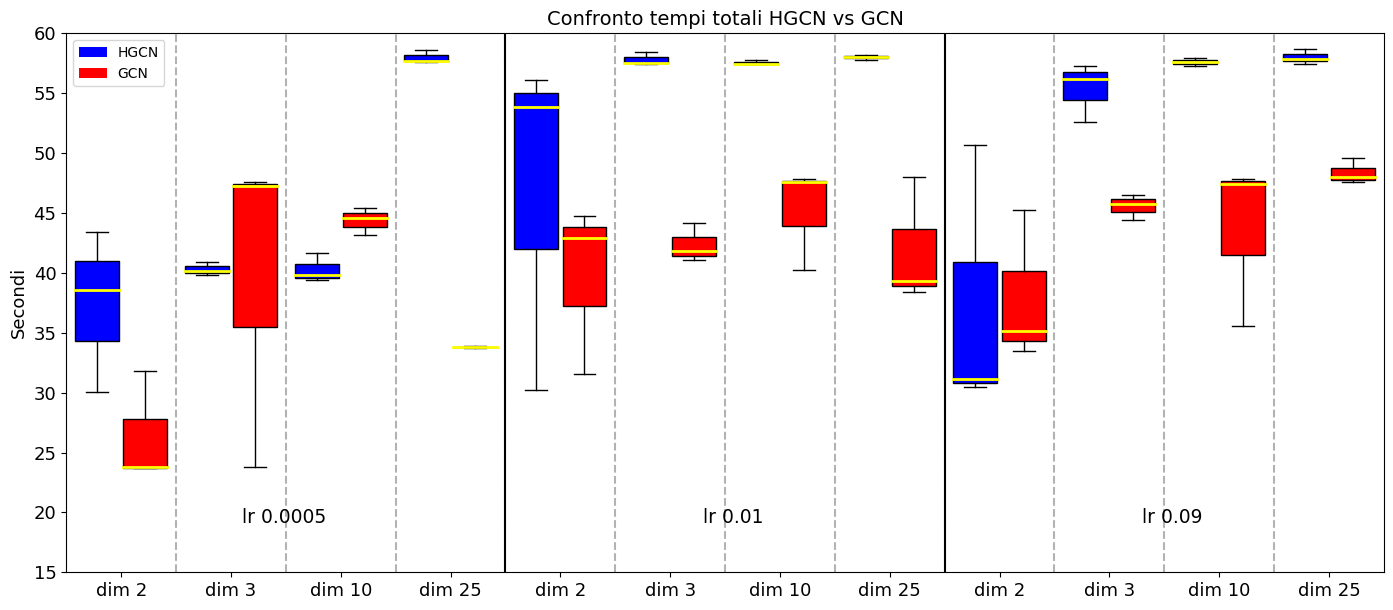

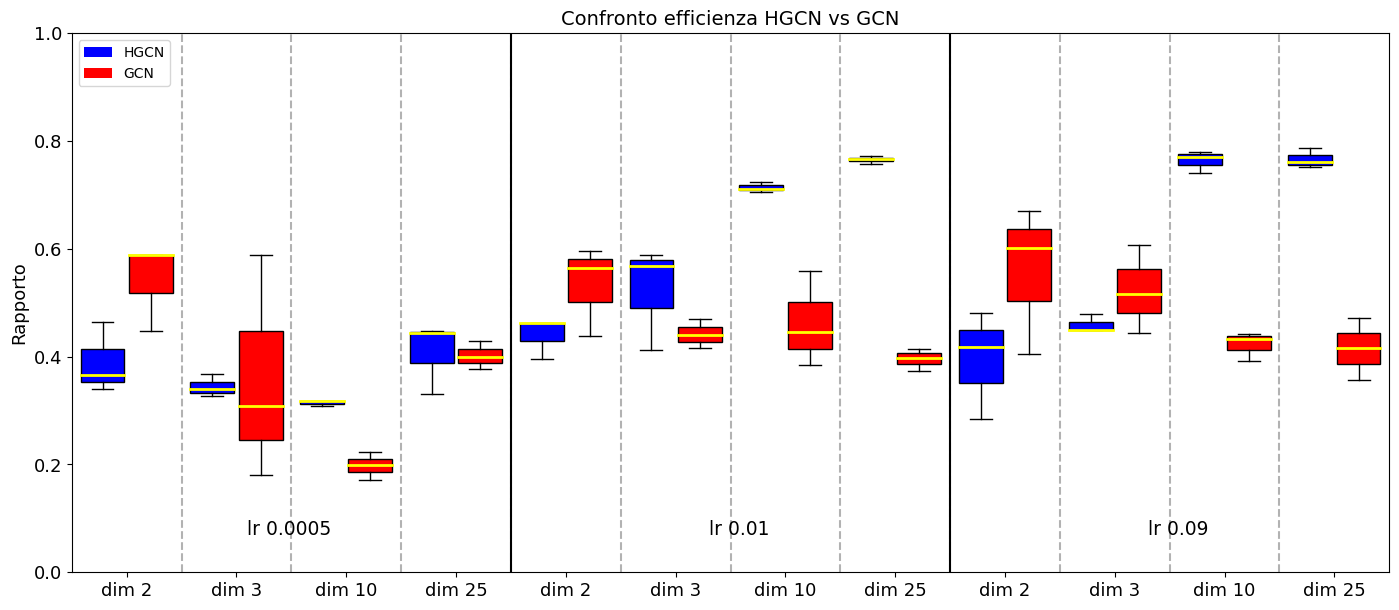

In [11]:
from utilities import boxes

boxes(grid, rocHGCN, rocGCN, "Confronto ROC HGCN vs GCN", "ROC")
boxes(grid, SUMtimeHGCN, SUMtimeGCN, "Confronto tempi totali HGCN vs GCN", "Secondi", True)
boxes(grid, effHGCN, effGCN, "Confronto efficienza HGCN vs GCN", "Rapporto")

## Andamento ROC e tempo per combinazione di parametri e HGCN vs GCN

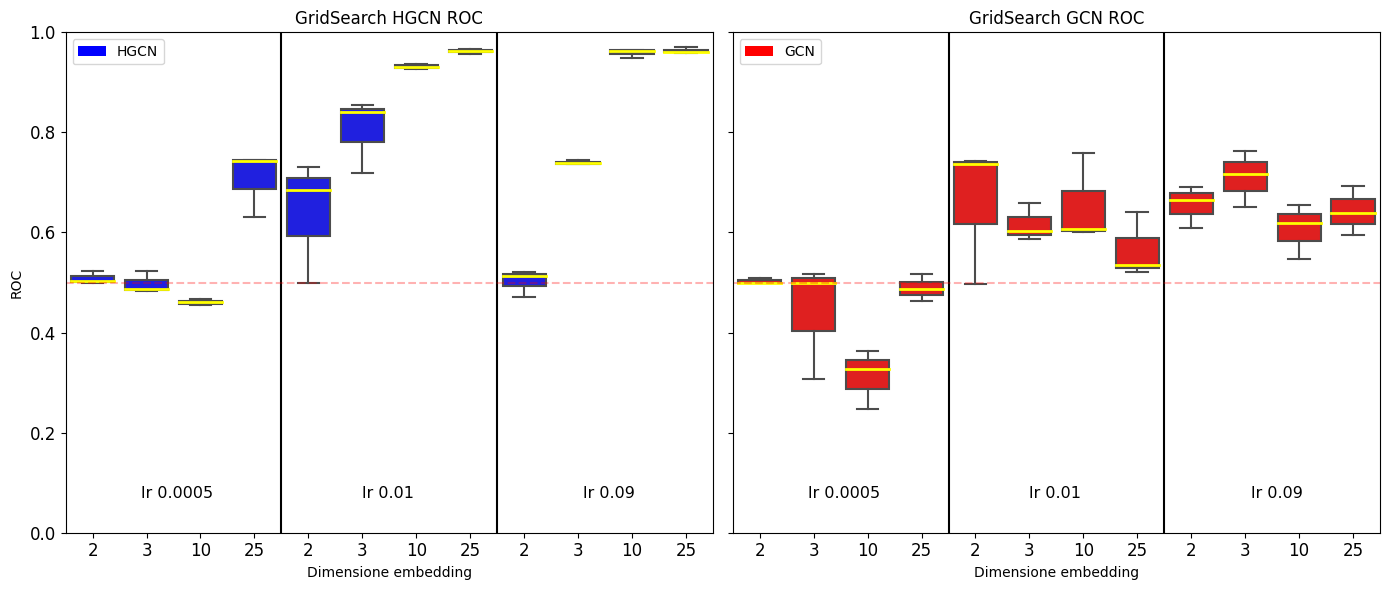

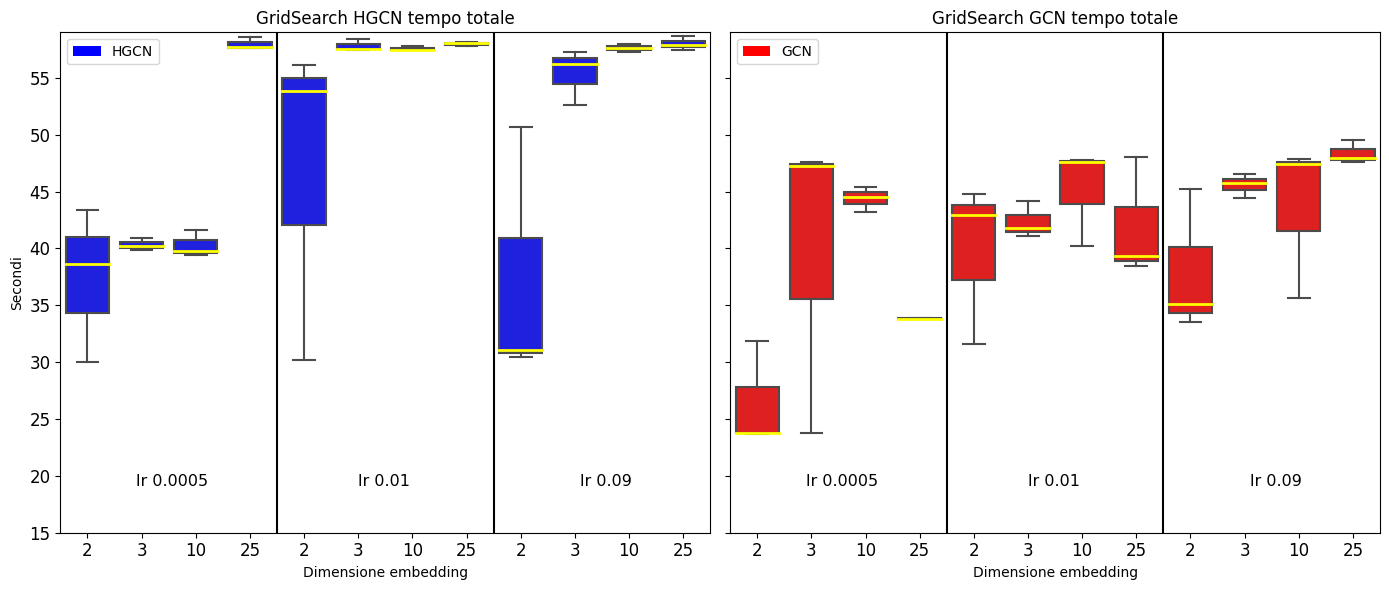

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
from utilities import andamentoBOX

andamentoBOX(rocHGCN, rocGCN, "ROC", "ROC", True)
andamentoBOX(SUMtimeHGCN, SUMtimeGCN, "tempo totale", "Secondi", False, True)

## Analisi efficienza

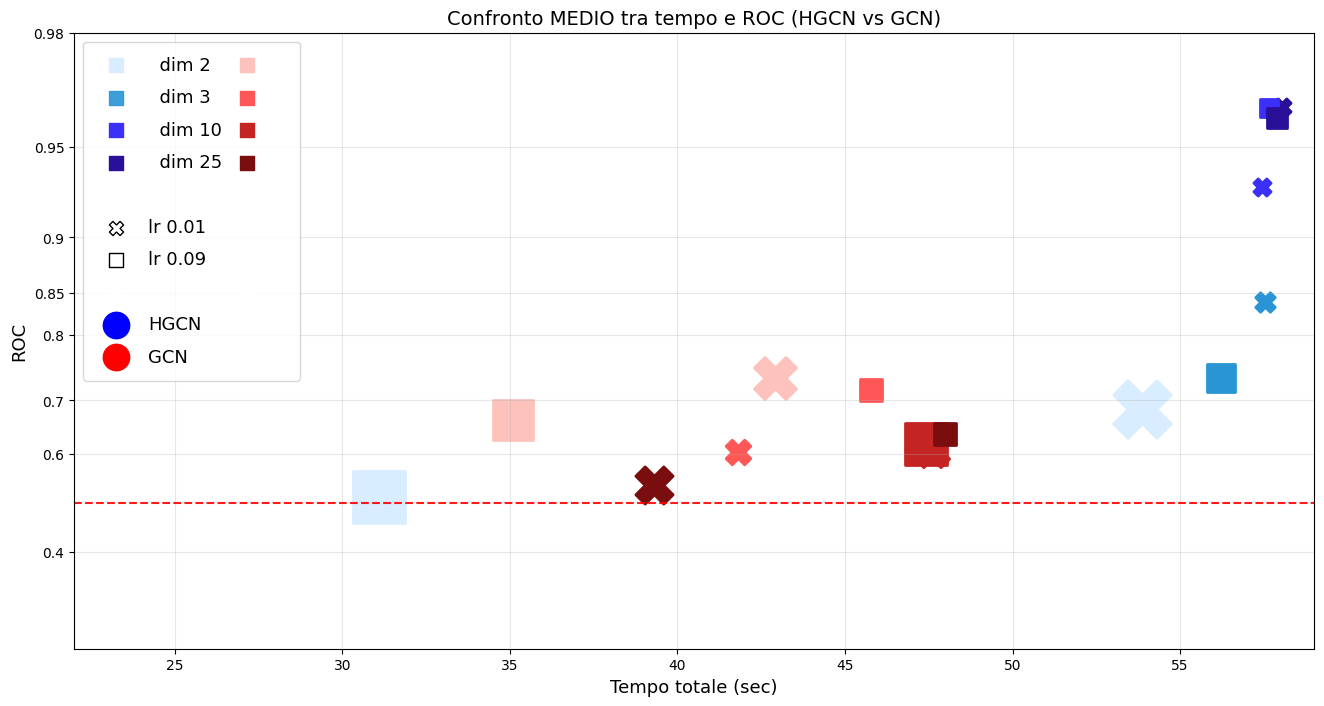

In [13]:
from utilities import scatterP

l = 0

for i in range(3):
    j = 4*l
    f = (4*l)+4

    SUMtimeHGCN[i] = SUMtimeHGCN[i][:j] + SUMtimeHGCN[i][f:]
    SUMtimeGCN[i]  = SUMtimeGCN[i][:j] + SUMtimeGCN[i][f:]
    rocHGCN[i] = rocHGCN[i][:j] + rocHGCN[i][f:]
    rocGCN[i] = rocGCN[i][:j] + rocGCN[i][f:]
scatterP(SUMtimeHGCN, SUMtimeGCN, rocHGCN, rocGCN, l)